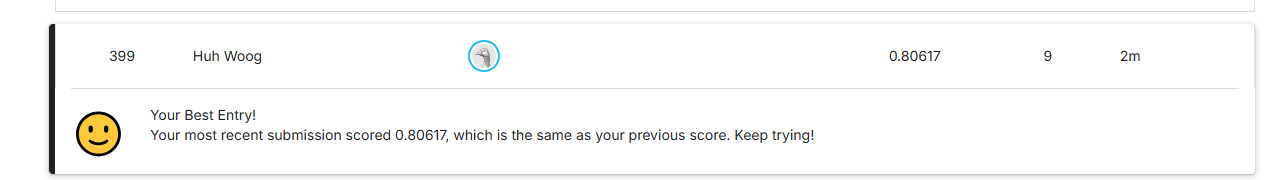

# [MAIN QUEST 01] Spaceship Titanic: EDA 기반 차원 이동 예측(어떤 승객들이 다른 차원으로 이동하게 될지 예측)

### 1. 분석 목표
#### Spaceship Titanic호 승객 데이터를 활용하여 차원 이동(Transported) 여부를 예측하는 프로젝트입니다. 탐색적 데이터 분석(EDA)을 통해 발견한 패턴을 논리적인 전처리 전략으로 연결하는 데 집중합니다.

### 2. 주요 진행 방향
#### 2.1 EDA 및 시각화 인사이트
#### 2.2 논리적 전처리 및 피처 엔지니어링
#### 2.3 모델링 및 결과 분석

### 3. 분석 프로세스
#### 3.1 Data Load: 데이터 구조 및 결측치 현황 파악
#### 3.2 EDA: 시각화를 통한 인사이트 도출 및 가설 검증
#### 3.3 Preprocessing: 논리적 근거에 기반한 전처리 및 피처 생성
#### 3.4 Modeling: 머신러닝 모델 학습 및 성능 평가
#### 3.5 Insight: 피처 중요도 분석 및 최종 결과 도출

### 4. 라이브러이 및 데이터 확인

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import warnings
warnings.filterwarnings('ignore')

# 시각화 기본 설정
plt.style.use('ggplot')
sns.set_palette('husl')


In [2]:
# 데이터 로드
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')
sample_submission = pd.read_csv('sample_submission.csv')

# 기본 정보 확인
print(f"Train Shape: {train_df.shape}")
print(f"Test Shape: {test_df.shape}")
train_df.head()


Train Shape: (8693, 14)
Test Shape: (4277, 13)


,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


##### 전체 승객 수: 8,693(Train) + 4,277(Test) = 12,970명
##### Train 비율: 8,693 / 12,970 ≈ 67%
##### Test 비율: 4,277 / 12,970 ≈ 33%

### 5. 데이터 기초 통계 및 결측치 분석

In [3]:
# 기초 통계량
display(train_df.describe())

# 결측치 확인
missing_train = train_df.isnull().sum()
missing_test = test_df.isnull().sum()
print("### Missing Values in Train ###")
print(missing_train[missing_train > 0])

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
count,8514.000000,8512.000000,8510.000000,8485.000000,8510.000000,8505.000000
mean,28.827930,224.687617,458.077203,173.729169,311.138778,304.854791
std,14.489021,666.717663,1611.489240,604.696458,1136.705535,1145.717189
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,19.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,38.000000,47.000000,76.000000,27.000000,59.000000,46.000000
max,79.000000,14327.000000,29813.000000,23492.000000,22408.000000,24133.000000


### Missing Values in Train ###
HomePlanet      201
CryoSleep       217
Cabin           199
Destination     182
Age             179
VIP             203
RoomService     181
FoodCourt       183
ShoppingMall    208
Spa             183
VRDeck          188
Name            200
dtype: int64


##### 1. 결측치 현황: 모든 주요 변수에서 약 2.3%(180~220개)의 결측치가 고르게 발견되었다.
##### 2. 지출 패턴: 승객의 절반 이상이 편의시설 지출이 0이며, 이는 냉동 수면(CryoSleep) 상태와 밀접한 관련성 있음이 추정
##### 3. 이상치 존재: 평균 대비 최대 지출액이 매우 높아, 소수의 고액 지출자(VIP 등)가 존재함
##### 4. 연령 분포: 평균 연령은 약 28.8세이며, 영유아부터 고령층까지 폭넓게 분포되어 있다.
##### 5. 대응 전략: 시각화(EDA)를 통해 위 변수들이 차원 이동(Transported)에 미치는 영향을 검증한 후 논리적으로 결측치를 처리할 예정

### EDA: 타겟 변수 분포 확인

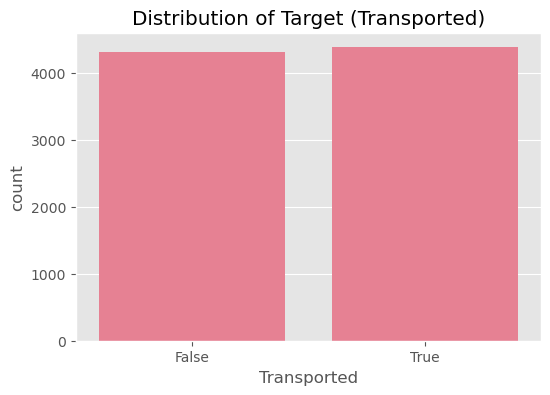

Target Ratio:
Transported
True     0.503624
False    0.496376
Name: proportion, dtype: float64


In [4]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Transported', data=train_df)
plt.title('Distribution of Target (Transported)')
plt.show()

print(f"Target Ratio:\n{train_df['Transported'].value_counts(normalize=True)}")

##### True (차원 이동 됨): 약 50.36%
##### False (차원 이동 안 됨): 약 49.64%

### 7.  EDA: 범주형 변수와 차원 이동 관계

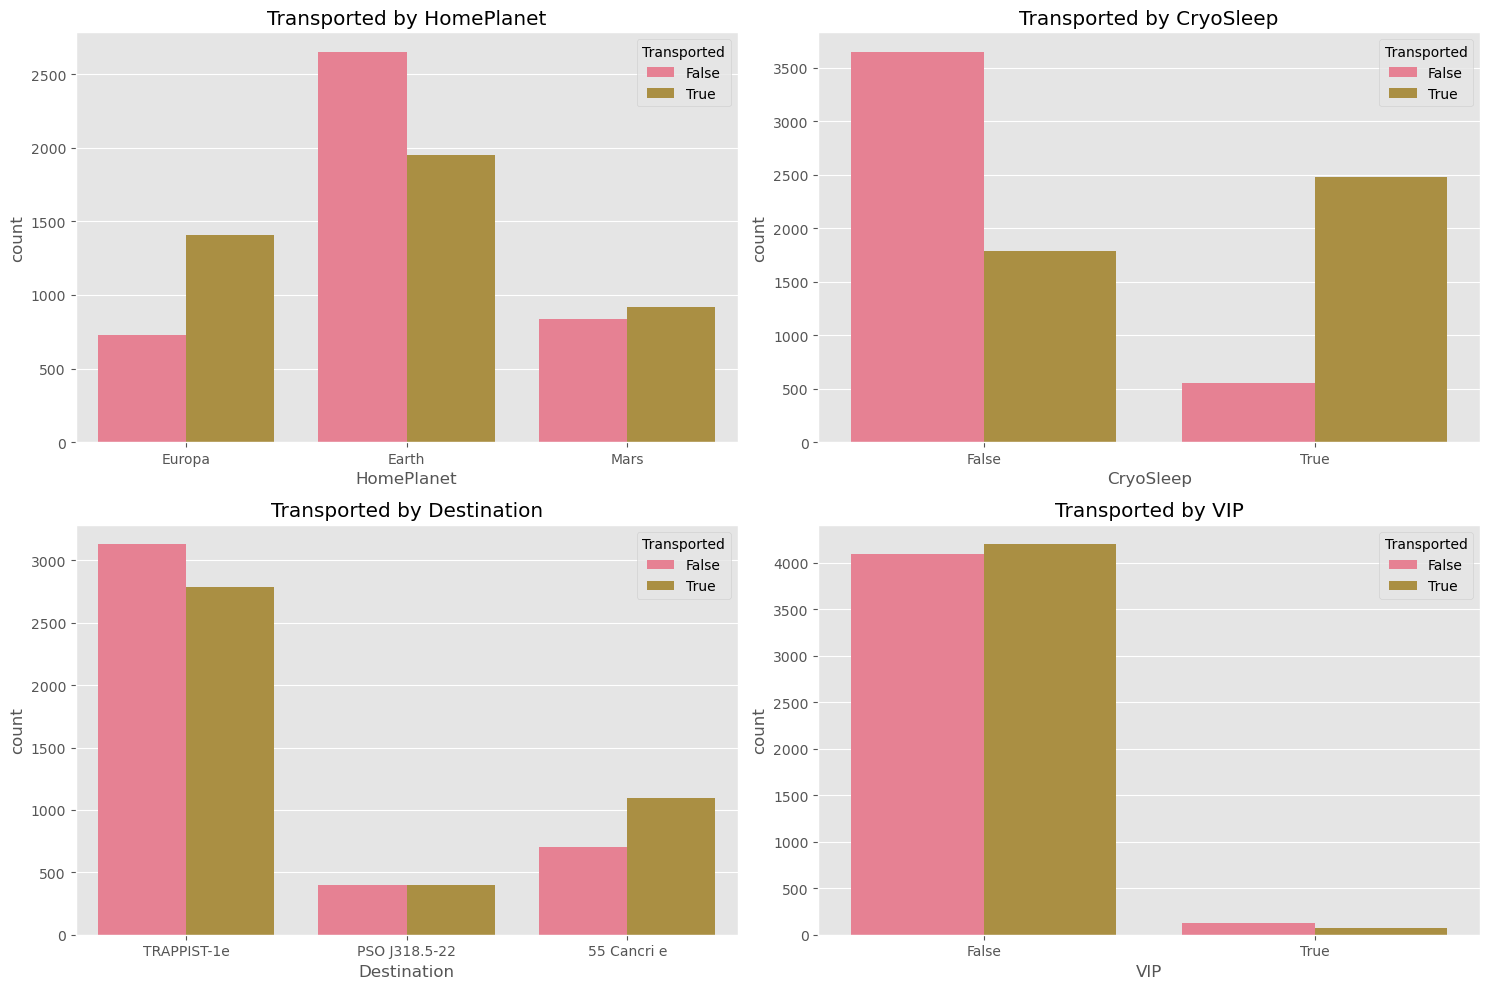

In [5]:
cat_features = ['HomePlanet', 'CryoSleep', 'Destination', 'VIP']
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

for i, col in enumerate(cat_features):
    sns.countplot(data=train_df, x=col, hue='Transported', ax=axes[i//2, i%2])
    axes[i//2, i%2].set_title(f'Transported by {col}')

plt.tight_layout()
plt.show()

##### CryoSleep (냉동 수면): 가장 강력한 변수이며, 냉동 수면 중인 승객의 차원 이동 확률이 압도적으로 높음을 보여준다.
##### HomePlanet (출신 행성): Europa 출신은 차원 이동 확률이 매우 높고, Earth 출신은 상대적으로 낮음을 보여준다
##### Destination (목적지): 55 Cancri e 목적지 승객이 다른 목적지보다 차원 이동 확률이 소폭 높음을 보여준다.
##### VIP 여부: VIP 여부는 차원 이동 확률에 거의 영향을 주지 않음 (두 그룹의 비율이 비슷함).

### 8.  EDA: 수치형 변수 및 지출 패턴 분석

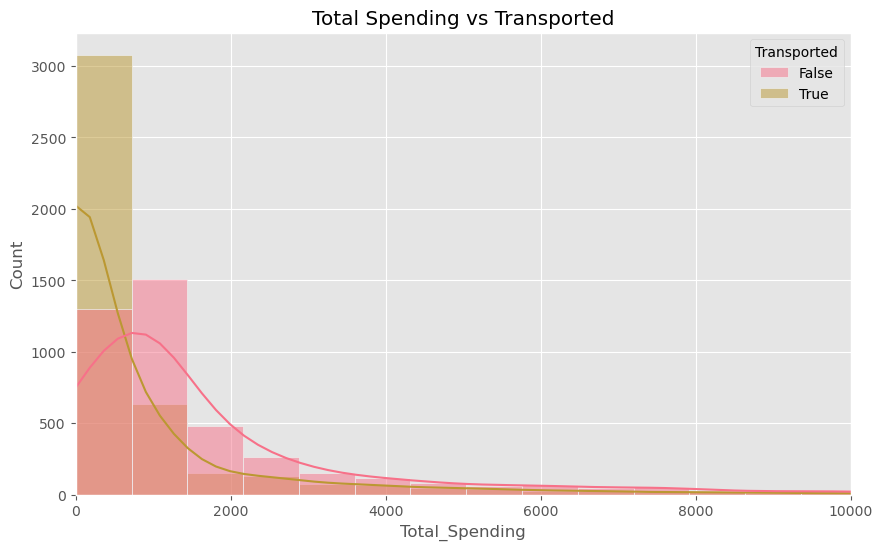

In [6]:
exp_features = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
train_df['Total_Spending'] = train_df[exp_features].sum(axis=1)

plt.figure(figsize=(10, 6))
sns.histplot(data=train_df, x='Total_Spending', hue='Transported', bins=50, kde=True)
plt.title('Total Spending vs Transported')
plt.xlim(0, 10000) # 시각화를 위해 범위 제한
plt.show()

##### 지출이 0원인 승객(냉동 수면자 추정)은 차원 이동 확률이 매우 높고, 지출이 있는 승객은 차원 이동 확률이 낮음을 보여준다.

### 9. EDA: 객실 위치 및 그룹 정보 탐색

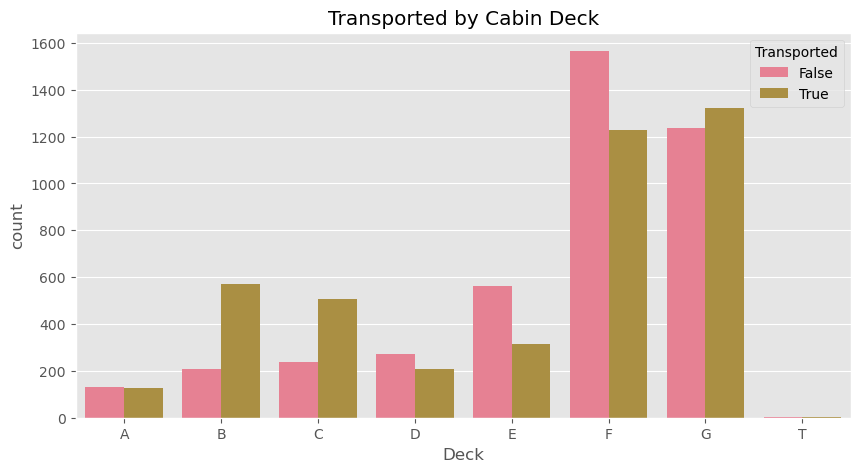

In [7]:
# Cabin 분리 시각화 준비
train_df['Deck'] = train_df['Cabin'].str.split('/', expand=True)[0]
plt.figure(figsize=(10, 5))
sns.countplot(data=train_df, x='Deck', hue='Transported', order=['A','B','C','D','E','F','G','T'])
plt.title('Transported by Cabin Deck')
plt.show()


##### 우주선의 위쪽 층(B, C)은 차원 이동 확률이 매우 높고, 아래쪽 층(E, F)은 상대적으로 안전한것으로 보인다.

### 10. 기타 숨겨진 특질들에 대한 탐색

### 10-1 승객의 나이 (Age)

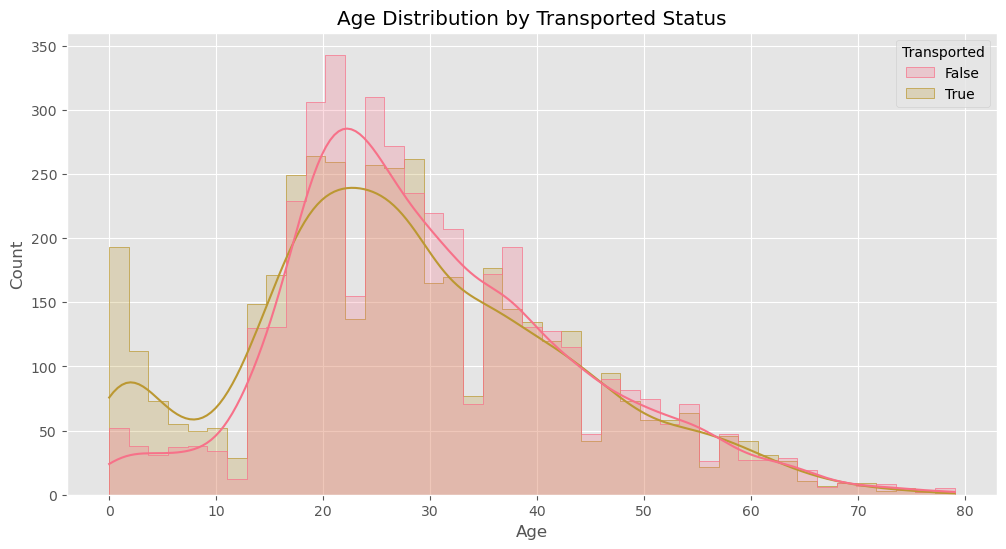

In [8]:
# 나이대별 차원 이동 확률 시각화
plt.figure(figsize=(12, 6))
sns.histplot(data=train_df, x='Age', hue='Transported', kde=True, element='step')
plt.title('Age Distribution by Transported Status')
plt.show()

##### 0~5세 영유아는 차원 이동 확률이 매우 높고, 20대 청년층은 배에 남을 확률이 높으며, 그 이상의 연령대는 나이의 영향력이 비교적 적음을 보여준다.

### 10-2  동행자 유무

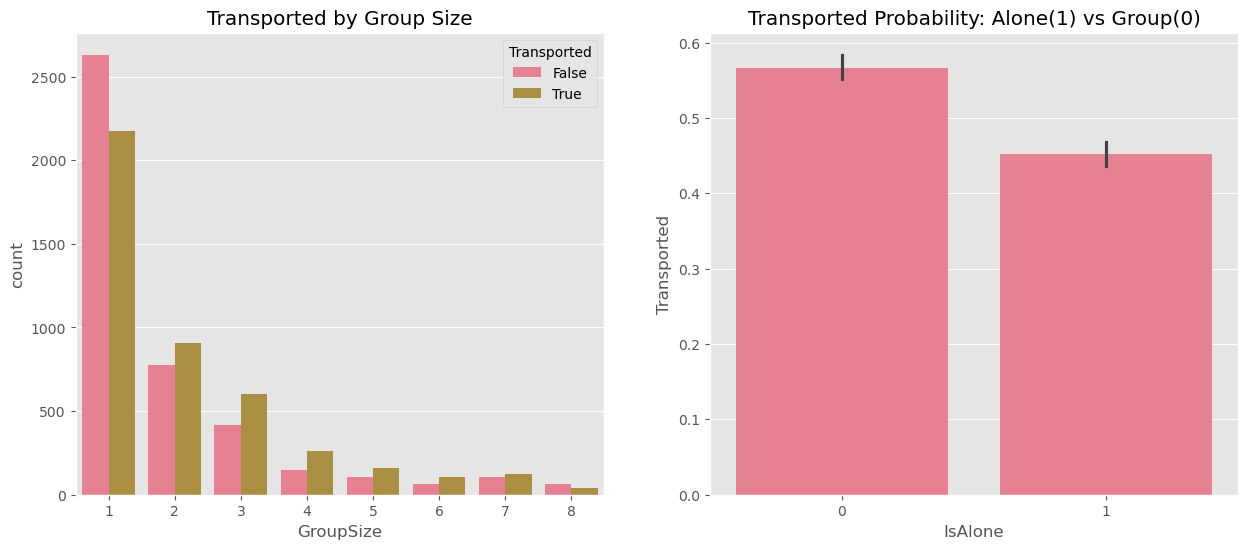

In [9]:
# 그룹 번호 추출 및 그룹 크기 계산
train_df['Group'] = train_df['PassengerId'].apply(lambda x: x.split('_')[0])
group_counts = train_df['Group'].value_counts().to_dict()
train_df['GroupSize'] = train_df['Group'].map(group_counts)
train_df['IsAlone'] = (train_df['GroupSize'] == 1).astype(int)

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.countplot(data=train_df, x='GroupSize', hue='Transported', ax=axes[0])
axes[0].set_title('Transported by Group Size')

sns.barplot(data=train_df, x='IsAlone', y='Transported', ax=axes[1])
axes[1].set_title('Transported Probability: Alone(1) vs Group(0)')
plt.show()

##### 혼자 온 승객보다 가족이나 친구 등 단체(Group)로 온 승객들의 차원 이동 확률이 훨씬 높음을 보여준다.

### 10-3 승객의 성씨(가족 단위) 분석

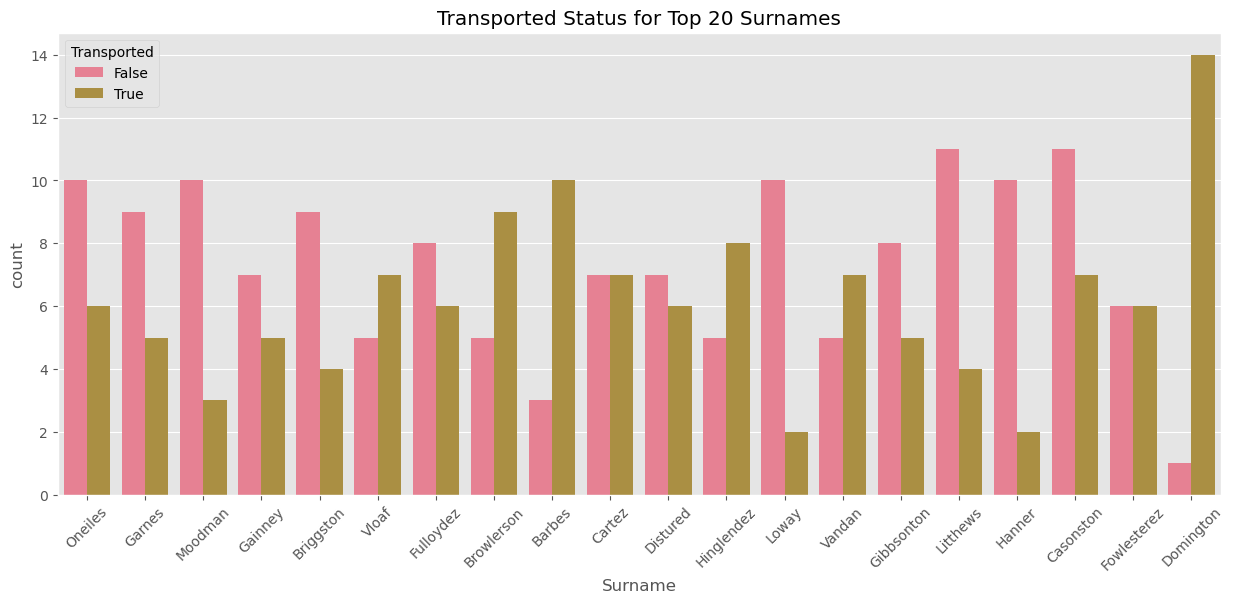

In [10]:


# 성(Surname) 추출 (결측치는 'Unknown' 처리)
train_df['Surname'] = train_df['Name'].str.split().str[-1].fillna('Unknown')

# 성씨별 차원 이동 빈도 계산 (상위 20개 성씨)
top_surnames = train_df['Surname'].value_counts().index[1:21] # Unknown 제외 상위 20개
plt.figure(figsize=(15, 6))
sns.countplot(data=train_df[train_df['Surname'].isin(top_surnames)], x='Surname', hue='Transported')
plt.xticks(rotation=45)
plt.title('Transported Status for Top 20 Surnames')
plt.show()

##### 그래프는 특정 성씨(가족) 내 승객들은 차원 이동 여부가 서로 매우 유사하게 나타나는 '가족 단위의 운명 공동체' 경향을 보여주고 잇다.

### 10-4 객실의 상세 위치(좌현/우현) 분석

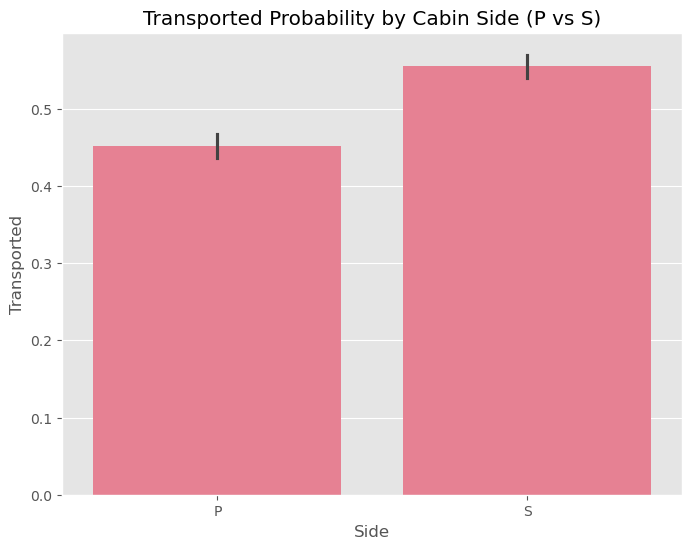

In [11]:

# Cabin Side 추출 (이미 전처리 함수에 포함되어 있다면 확인만)
train_df['Side'] = train_df['Cabin'].str.split('/', expand=True)[2]

plt.figure(figsize=(8, 6))
sns.barplot(data=train_df, x='Side', y='Transported', order=['P', 'S'])
plt.title('Transported Probability by Cabin Side (P vs S)')
plt.show()

##### 우주선의 우측(S, Starboard) 객실에 머물렀던 승객들이 좌측(P, Port) 승객들보다 차원 이동 확률이 눈에 띄게 높게 나타나는 것을 보여준다.

### 11. 탐색적 테이터 분석의 요약

### 탐색적 데이터 분석(EDA)을 통해 확인한 차원 이동(Transported)의 핵심 결정 요인들
#### 1. 냉동 수면(CryoSleep)의 결정적 영향:
##### 냉동 수면 중인 승객은 깨어 있는 승객보다 차원 이동 확률이 압도적으로 높음.
##### 이는 사고 당시 격리된 상태가 이상 현상에 더 취약했음을 시사

#### 2. 지출 패턴과 차원 이동의 상관관계:
##### 편의시설 지출이 0원인 승객(주로 냉동 수면자)의 차원 이동 비율이 매우 높음.
##### 반면, 지출이 많은 승객일수록 차원 이동이 되지 않고 배에 남을 확률이 높음.

#### 3.객실 위치(Cabin Deck)에 따른 위험도 차이:
##### B, C층(위쪽 층): 차원 이동 확률이 매우 높은 '위험 구역'으로 분석됨.
##### E, F층(아래쪽 층): 상대적으로 차원 이동 확률이 낮은 '안전 구역'으로 분석됨.

### 4. 출신 행성(HomePlanet)의 영향:
##### Europa 출신 승객은 차원 이동 확률이 높고, Earth 출신 승객은 상대적으로 낮음.
##### 이는 행성별 승객들의 객실 배치나 사회경제적 특성이 결과에 반영된 것으로 보임.

### 5. 승객의 나이
##### 0~5세 영유아는 차원 이동 확률이 매우 높고, 20대 청년층은 배에 남을 확률이 높으며, 그 이상의 연령대는 나이의 영향력이 비교적 적음

### 6. 동행자 유무
##### 혼자 온 승객보다 가족이나 친구 등 단체(Group)로 온 승객들의 차원 이동 확률이 훨씬 높다.

### 7. 승객의 성씨 단위 분석
##### 특정 성씨(가족) 내 승객들은 차원 이동 여부가 서로 매우 유사하게 나타나는 '가족 단위의 운명 공동체' 경향을 보인다.

### 8. 객실의 상세 위치 분석
##### 우주선의 우측(S, Starboard) 객실에 머물렀던 승객들이 좌측(P, Port) 승객들보다 차원 이동 확률이 눈에 띄게 높게 나타난다.

### 11. 데이터 전처리

In [12]:
# 1. Cabin 변수 분리 (Deck, Num, Side)
# 결측치는 임시로 'U/0/U' (Unknown)로 채운 후 분리합니다.
train_df['Cabin'] = train_df['Cabin'].fillna('U/0/U')
test_df['Cabin'] = test_df['Cabin'].fillna('U/0/U')

train_df[['Deck', 'Num', 'Side']] = train_df['Cabin'].str.split('/', expand=True)
test_df[['Deck', 'Num', 'Side']] = test_df['Cabin'].str.split('/', expand=True)

# 2. 지출 관련 변수 합산 및 결측치 처리
spending_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']

# 냉동 수면(CryoSleep) 중인 사람은 지출이 0이라는 논리 적용
for col in spending_cols:
    train_df.loc[(train_df[col].isnull()) & (train_df['CryoSleep'] == True), col] = 0
    test_df.loc[(test_df[col].isnull()) & (test_df['CryoSleep'] == True), col] = 0
    # 나머지 결측치는 중앙값으로 채움
    train_df[col] = train_df[col].fillna(train_df[col].median())
    test_df[col] = test_df[col].fillna(test_df[col].median())

# 총 지출액 계산
train_df['Total_Spending'] = train_df[spending_cols].sum(axis=1)
test_df['Total_Spending'] = test_df[spending_cols].sum(axis=1)

train_df['LuxurySpend'] = train_df['Spa'] + train_df['VRDeck']
test_df['LuxurySpend'] = test_df['Spa'] + test_df['VRDeck']


# 3. 기타 범주형 및 수치형 변수 결측치 처리
# 범주형은 최빈값(mode), 수치형은 중앙값(median)으로 처리
cols_to_fix = {
    'HomePlanet': train_df['HomePlanet'].mode()[0],
    'CryoSleep': train_df['CryoSleep'].mode()[0],
    'Destination': train_df['Destination'].mode()[0],
    'VIP': train_df['VIP'].mode()[0],
    'Age': train_df['Age'].median()
}

for col, val in cols_to_fix.items():
    train_df[col] = train_df[col].fillna(val)
    test_df[col] = test_df[col].fillna(val)

# 4. 그룹 정보 생성 (PassengerId 활용)
train_df['Group'] = train_df['PassengerId'].apply(lambda x: x.split('_')[0])
test_df['Group'] = test_df['PassengerId'].apply(lambda x: x.split('_')[0])

group_size = pd.concat([train_df['Group'], test_df['Group']]).value_counts().to_dict()
train_df['GroupSize'] = train_df['Group'].map(group_size)
test_df['GroupSize'] = test_df['Group'].map(group_size)

train_df['IsAlone'] = (train_df['GroupSize'] == 1).astype(int)
test_df['IsAlone'] = (test_df['GroupSize'] == 1).astype(int)

for col in ['HomePlanet', 'Destination', 'CryoSleep', 'VIP']:
    train_df[col] = train_df.groupby('Group')[col].transform(
        lambda x: x.ffill().bfill()
    )
    test_df[col] = test_df.groupby('Group')[col].transform(
        lambda x: x.ffill().bfill()
    )


# 5. 불필요한 컬럼 제거
drop_cols = ['Cabin', 'Name', 'Group']
train_df.drop(columns=drop_cols, inplace=True)
test_df.drop(columns=drop_cols, inplace=True)

# --- 결과 확인 ---
print(f"Train Missing Values: {train_df.isnull().sum().sum()}")
print(f"Test Missing Values: {test_df.isnull().sum().sum()}")
print("\n--- 생성된 파생 변수 확인 ---")
display(train_df[['Deck', 'Num', 'Side', 'GroupSize', 'Total_Spending']].head())


Train Missing Values: 0
Test Missing Values: 0

--- 생성된 파생 변수 확인 ---


,Deck,Num,Side,GroupSize,Total_Spending
0,B,0,P,1,0.0
1,F,0,S,1,736.0
2,A,0,S,2,10383.0
3,A,0,S,2,5176.0
4,F,1,S,1,1091.0


### 결측치처리 결과: Train 0개, Test 0개로 해소됨
##### Cabin 결측치는 'Unknown'으로 임시 처리 후 Deck/Num/Side로 분리
##### 지출 결측치는 CryoSleep=True인 승객은 0으로, 나머지는 중앙값으로 처리
##### HomePlanet 등 범주형은 최빈값, Age는 중앙값으로 처리
##### 같은 그룹(동행자) 내 정보를 활용한 그룹 기반 결측치 추가 보완

### 12. 범주형 변수 인코딩 및 데이터 스케일링

In [13]:
# 1. 'Num' 컬럼을 숫자로 변환 (문자열로 되어 있으므로 정수형으로 바꿉니다)
train_df['Num'] = train_df['Num'].astype(int)
test_df['Num'] = test_df['Num'].astype(int)

# 2. 범주형 변수들을 숫자로 변환 (Label Encoding)
# 모델이 글자를 읽지 못하므로 0, 1, 2... 같은 숫자로 바꿔줍니다.
le_cols = ['HomePlanet', 'CryoSleep', 'Destination', 'VIP', 'Deck', 'Side']

for col in le_cols:
    le = LabelEncoder()
    # Train과 Test에 있는 모든 값을 학습하여 변환합니다.
    train_df[col] = le.fit_transform(train_df[col].astype(str))
    test_df[col] = le.transform(test_df[col].astype(str))

# 3. 수치형 변수 스케일링 (Standard Scaling)
# 값의 범위가 너무 큰 변수들을 평균 0, 표준편차 1로 맞춰 모델의 학습을 돕습니다.
scaler = StandardScaler()
scale_cols = ['Age', 'Num', 'GroupSize', 'Total_Spending']

train_df[scale_cols] = scaler.fit_transform(train_df[scale_cols])
test_df[scale_cols] = scaler.transform(test_df[scale_cols])

# 4. 결과 확인
print("--- 인코딩 및 스케일링 완료 ---")
display(train_df.head())

--- 인코딩 및 스케일링 완료 ---


,PassengerId,HomePlanet,CryoSleep,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported,Total_Spending,Deck,GroupSize,IsAlone,Surname,Side,Num,LuxurySpend
0,0001_01,1,0,2,0.711945,0,0.0,0.0,0.0,0.0,0.0,False,-0.514066,1,-0.648735,1,Ofracculy,0,-1.141624,0.0
1,0002_01,0,0,2,-0.334037,0,109.0,9.0,25.0,549.0,44.0,True,-0.251479,5,-0.648735,1,Vines,1,-1.141624,593.0
2,0003_01,1,0,2,2.036857,1,43.0,3576.0,0.0,6715.0,49.0,False,3.190333,0,-0.022268,0,Susent,1,-1.141624,6764.0
3,0003_02,1,0,2,0.293552,0,0.0,1283.0,371.0,3329.0,193.0,False,1.332604,0,-0.022268,0,Susent,1,-1.141624,3522.0
4,0004_01,0,0,2,-0.891895,0,303.0,70.0,151.0,565.0,2.0,True,-0.124824,5,-0.648735,1,Santantines,1,-1.139678,567.0


In [14]:
# 삭제할 대상 컬럼 리스트
drop_final = ['PassengerId', 'Surname', 'Name', 'Group']

# 에러 방지를 위해 컬럼이 존재하는 경우에만 삭제 (errors='ignore')
X = train_df.drop(columns=drop_final + ['Transported'], errors='ignore')
y = train_df['Transported'].astype(int)

# 테스트 데이터도 동일하게 정리 (제출용 ID는 따로 보관)
test_passenger_ids = pd.read_csv('test.csv')['PassengerId'] # 나중에 제출할 때 필요함
X_test = test_df.drop(columns=drop_final, errors='ignore')

print("--- 모델 학습용 데이터 준비 완료 ---")
print(f"학습용 피처 개수: {len(X.columns)}")
print(f"피처 목록: {list(X.columns)}")

# 데이터 샘플 확인
display(X.head())

--- 모델 학습용 데이터 준비 완료 ---
학습용 피처 개수: 17
피처 목록: ['HomePlanet', 'CryoSleep', 'Destination', 'Age', 'VIP', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'Total_Spending', 'Deck', 'GroupSize', 'IsAlone', 'Side', 'Num', 'LuxurySpend']


,HomePlanet,CryoSleep,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Total_Spending,Deck,GroupSize,IsAlone,Side,Num,LuxurySpend
0,1,0,2,0.711945,0,0.0,0.0,0.0,0.0,0.0,-0.514066,1,-0.648735,1,0,-1.141624,0.0
1,0,0,2,-0.334037,0,109.0,9.0,25.0,549.0,44.0,-0.251479,5,-0.648735,1,1,-1.141624,593.0
2,1,0,2,2.036857,1,43.0,3576.0,0.0,6715.0,49.0,3.190333,0,-0.022268,0,1,-1.141624,6764.0
3,1,0,2,0.293552,0,0.0,1283.0,371.0,3329.0,193.0,1.332604,0,-0.022268,0,1,-1.141624,3522.0
4,0,0,2,-0.891895,0,303.0,70.0,151.0,565.0,2.0,-0.124824,5,-0.648735,1,1,-1.139678,567.0


##### 문자형 데이터를 숫자로 변환(Label Encoding)
##### 서로 다른 단위의 수치 데이터를 표준화(Standard Scaling)
##### 머신러닝 모델이 모든 피처를 공정하고 효율적으로 학습할 수 있는 환경을 구축완료

### 13. 모델 학습용 데이터 분할

In [15]:
# 데이터를 8:2 비율로 분할
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"학습용 데이터 수: {len(X_train)}")
print(f"검증용 데이터 수: {len(X_val)}")

학습용 데이터 수: 6954
검증용 데이터 수: 1739


### 14.  머신러닝 모델 선택 및 학습

In [16]:
# 1. Random Forest 모델 학습
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# 2. LightGBM 모델 학습 (속도가 빠르고 성능이 좋습니다)
from lightgbm import LGBMClassifier
lgbm_model = LGBMClassifier(n_estimators=100, random_state=42, verbose=-1)
lgbm_model.fit(X_train, y_train)

print('--- 모델 학습 완료 ---')

--- 모델 학습 완료 ---


### 15. 모델 성능 평가

In [17]:
from sklearn.metrics import accuracy_score
rf_preds = rf_model.predict(X_val)
lgbm_preds = lgbm_model.predict(X_val)

print(f'Random Forest 정확도: {accuracy_score(y_val, rf_preds):.4f}')
print(f'LightGBM 정확도: {accuracy_score(y_val, lgbm_preds):.4f}')

Random Forest 정확도: 0.7792
LightGBM 정확도: 0.8074


### 16. 하이퍼파라미터 튜닝

In [18]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'num_leaves': [31, 63]
}

grid_lgbm = GridSearchCV(LGBMClassifier(random_state=42, verbose=-1), 
                         param_grid, cv=3, scoring='accuracy', n_jobs=-1)
grid_lgbm.fit(X_train, y_train)

best_lgbm = grid_lgbm.best_estimator_
tuned_preds = best_lgbm.predict(X_val)

print(f"최적의 하이퍼파라미터: {grid_lgbm.best_params_}")
print(f"튜닝 후 LightGBM 정확도: {accuracy_score(y_val, tuned_preds):.4f}")

최적의 하이퍼파라미터: {'learning_rate': 0.05, 'max_depth': 7, 'n_estimators': 200, 'num_leaves': 31}
튜닝 후 LightGBM 정확도: 0.8108


##### GridSearchCV를 통해 탐색한 결과, 최적의 하이퍼파라미터는 아래와 같다.
##### learning_rate: 0.05 (너무 크지 않게 안정적으로 학습)
##### max_depth: 7 (트리 깊이 7단계로 복잡한 패턴까지 학습)
##### n_estimators: 200 (트리 200개로 앙상블)
##### num_leaves: 31 (각 트리의 최대 잎 노드 수)
##### 튜닝 결과 LightGBM 정확도 0.8108로, 기본 모델 대비 성능이 향상되었습니다.

### 17. 제출용 파일 생성

In [19]:
# 1. test_df에 누락된 IsAlone 컬럼 생성 (GroupSize가 1이면 1, 아니면 0)
if 'IsAlone' not in test_df.columns:
    test_df['IsAlone'] = (test_df['GroupSize'] == 1).astype(int)
    print("test_df에 'IsAlone' 컬럼을 생성했습니다.")

# 2. 학습에 사용된 컬럼 리스트 확인
model_features = list(X_train.columns)

# 3. test_df에서 학습 피처들만 추출하여 X_test 생성
X_test = test_df[model_features]
print(f"X_test 준비 완료! 피처 개수: {len(X_test.columns)}")

# 4. 테스트 데이터 예측 수행
final_preds = best_lgbm.predict(X_test)

# 5. 제출용 데이터프레임 생성 (test.csv에서 ID 로드)
import pandas as pd
test_df_raw = pd.read_csv('test.csv')

submission = pd.DataFrame({
    'PassengerId': test_df_raw['PassengerId'],
    'Transported': final_preds.astype(bool)
})

# 6. 파일 저장
submission.to_csv('submission.csv', index=False)

print("\n--- [최종 성공] submission.csv 파일이 생성되었습니다! ---")
display(submission.head())

X_test 준비 완료! 피처 개수: 17

--- [최종 성공] submission.csv 파일이 생성되었습니다! ---


,PassengerId,Transported
0,0013_01,True
1,0018_01,False
2,0019_01,True
3,0021_01,True
4,0023_01,True


## 요약

### Spaceship Titanic 데이터를 활용해 승객의 차원 이동 여부를 예측하였고 데이터가 말해주는 내용들은 다음과 같다.

##### 1. CryoSleep(냉동 수면) 여부가 차원 이동을 결정하는 가장 강력한 변수였다.
##### 2. 편의시설 지출이 0원인 승객은 차원 이동 확률이 높고, 지출이 많을수록 낮아지는 패턴을 확인
##### 3. Cabin의 Deck(층)과 Side(좌/우)가 위치에 따라 차원 이동 확률에 뚜렷한 차이를 보였다.
##### 4. 같은 그룹(동행자)끼리는 HomePlanet, CryoSleep 등의 정보가 동일한 경향이 있어, 그룹 기반 결측치 처리가 효과적이었다.

### 최종 모델 성능 

#### 모델: LightGBM (GridSearchCV 하이퍼파라미터 튜닝 적용)
#### Validation Accuracy: 약 0.8108
#### Kaggle Public Score: **0.80617**

## 회고

#### 다양한 특질들을 피처 엔지니어링하고 시각화하는 과정이 데이터를 이해하는 데 가장 의미 있는 시간이었고 이번 프로젝트를 통해 데이터 분석가는 단순히 모델을 돌리는 사람이 아니라, 숫자를 보고 현상을 설명할 수 있어야 한다는 것을 깨닫게 되었다.앞으로는 데이터의 숫자들이 말해주는 것에 더 깊은 관심을 갖고, 숫자 뒤에 숨어 있는 현상과 맥락을 읽는 능력을 키워보고 싶다.

## 참조 

##### Kaggle Competition: [Spaceship Titanic](https://www.kaggle.com/competitions/spaceship-titanic)